Problem Statement: Analyze all relevant customer data and develop focused customer retention programs

In [110]:
import warnings
warnings.filterwarnings('ignore')

Import Libraries as per requirement

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [112]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [113]:
df = pd.read_csv('Telco_Customer_Churn.csv')

In [114]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [115]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


There are no null columns in the dataset, so we can safely ignore the imputation part

In [117]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [118]:
column_list = df.columns.to_list()
column_list

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [119]:
view = ['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [120]:
for col in view:
  print(df[col].value_counts(normalize=True))
  print()

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64

Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64

Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64

PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64

MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

OnlineSecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64

OnlineBackup
No                     0.438450
Yes                    0.344881
No internet service    0.216669
Name: proportion, dtype: float64

DeviceProtection
No                     0.439443
Yes                  

Except for the SeniorCitizen and PhoneService column, the dataset seems to be balanced

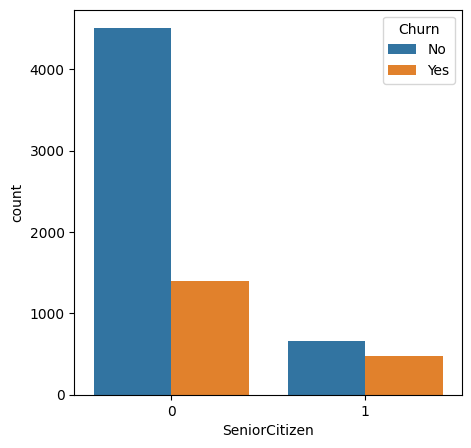

In [121]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.show()

Rate of churn among senior citizens seems to be quite high as compared to non-senior citizens.

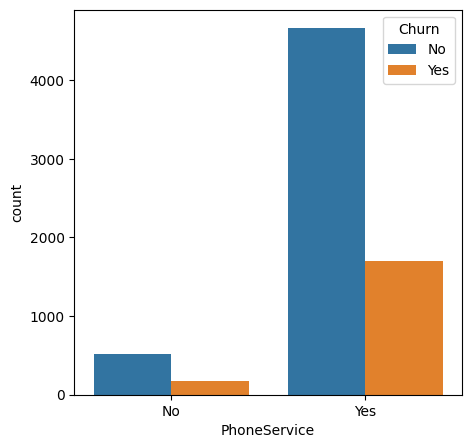

In [122]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='PhoneService', hue='Churn')
plt.show()

Above trend is not so much concerning and is a weak predictor. We would be dropping this column later

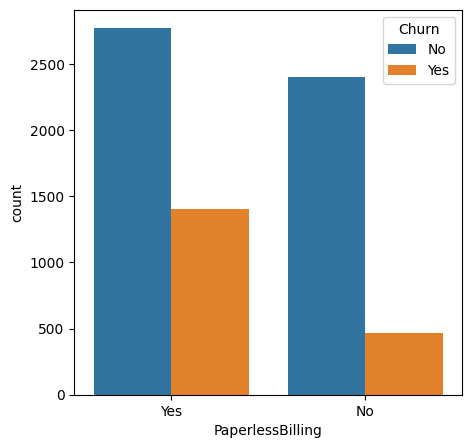

In [123]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.show()

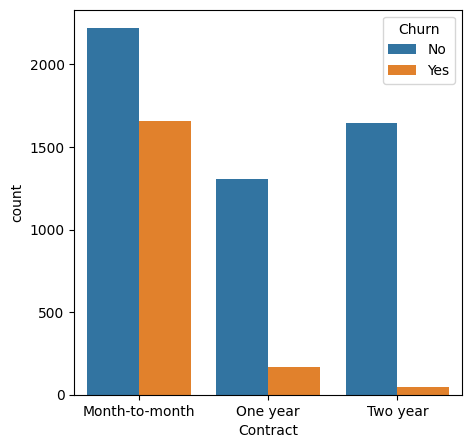

In [124]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.show()

Above column 'Contract' seems to be one of the most important columns. We should incentivize those on Month-to-month contract to sign one year contract and preferably two year contract by offering services, internet speed, streaming services etc.

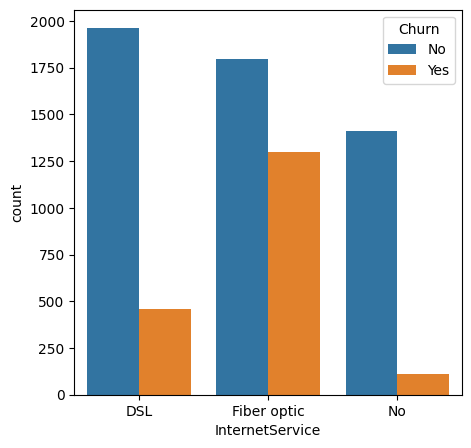

In [125]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.show()

Customer opting for fiber-optic service expect higher quality. It seems that the service provided does not seem to satisfy them. Customers opting for fiber optic service should be given preferential treatment as far as issue resolution is concerned.

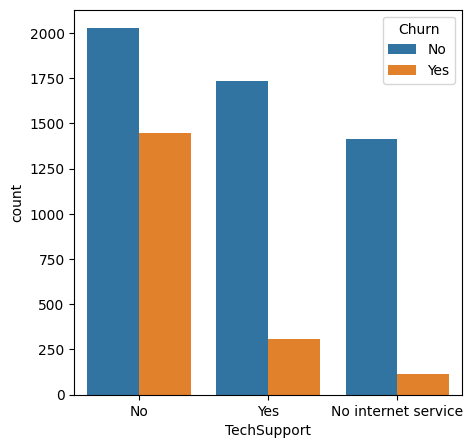

In [126]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.show()

Customers opting for tech support seem to have lower rate of churn as compared to the ones opting for no tech support

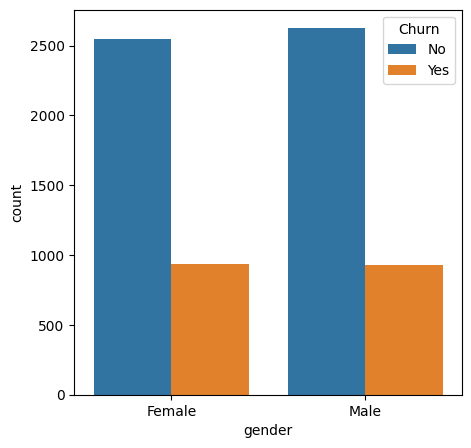

In [127]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='gender', hue='Churn')
plt.show()

Above column seems to be a very weak predictor as well. We would be dropping this later

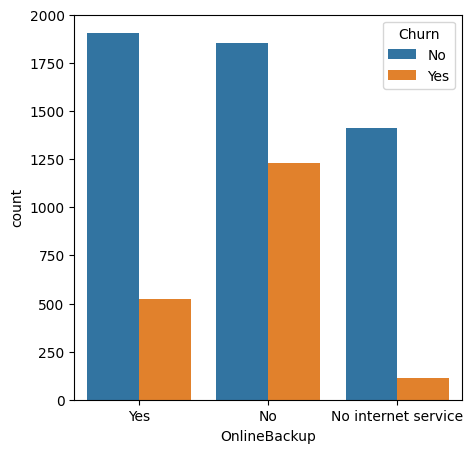

In [128]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='OnlineBackup', hue='Churn')
plt.show()

Customers opting for online backup have much lower rate of churn

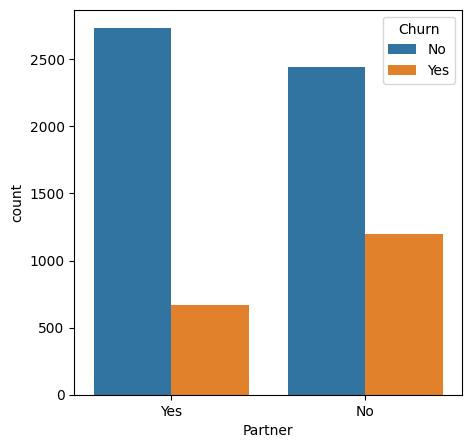

In [129]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='Partner', hue='Churn')
plt.show()

Consumers having partner seem to have lower rate of churn, will look into this

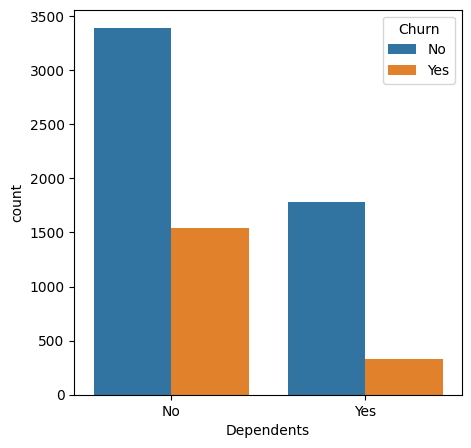

In [130]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.show()

Both partnered and dependent households have a similar rate of churn if no is a value.
Also, both columns seem to be correlated

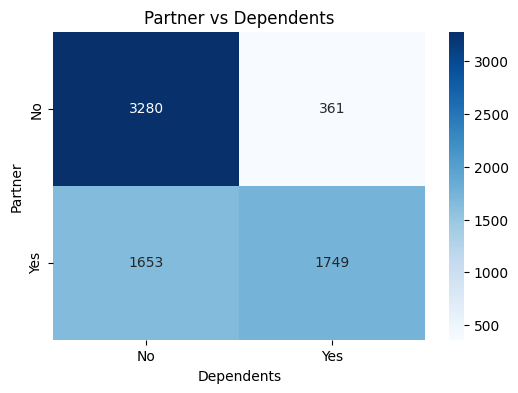

In [131]:
# Create a frequency table of Partner vs Dependents
cross_tab = pd.crosstab(df['Partner'], df['Dependents'])

plt.figure(figsize=(6, 4))
# Plot it as a heatmap so the colors show the density
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Partner vs Dependents')
plt.show()

In [132]:
# Feature engineering a HaveFamily column using Partner and Dependents

df['HaveFamily'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)

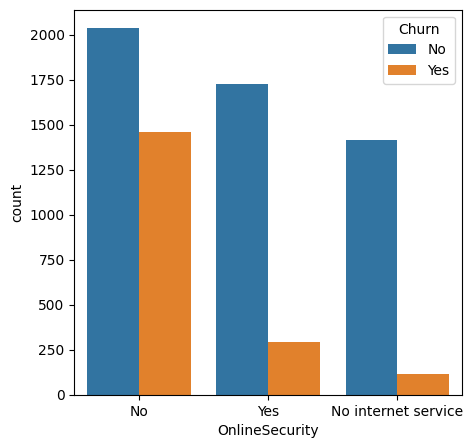

In [133]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.show()

Customers opting for online security seem to have far lower rate of churn as compared to the ones opting no.

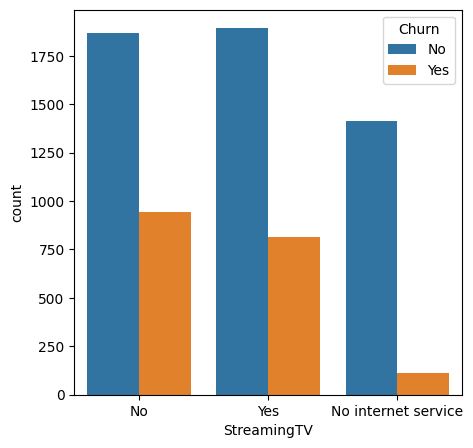

In [134]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='StreamingTV', hue='Churn')
plt.show()

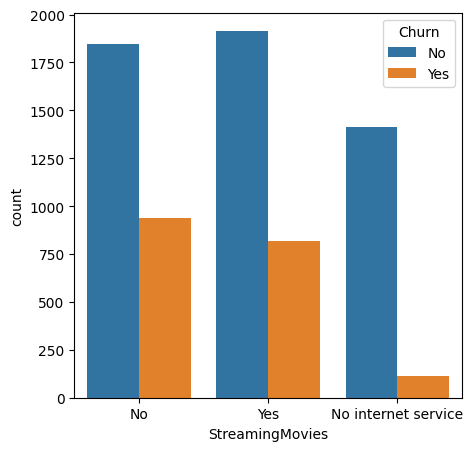

In [135]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='StreamingMovies', hue='Churn')
plt.show()

Both StreamingMovies and StreamingTV seem to be heavily collinear. We can combine them into one Has_Streaming_Service column

In [136]:
df['Has_Streaming_Service'] = ((df['StreamingMovies'] == 'Yes') | (df['StreamingTV'] == 'Yes')).astype(int)

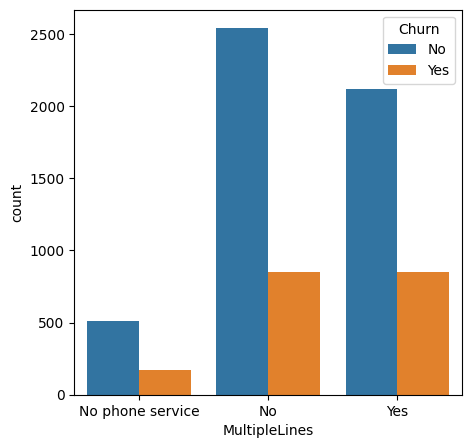

In [137]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='MultipleLines', hue='Churn')
plt.show()

We should be dropping the above column as well

In [138]:
df.drop(columns=['gender', 'PhoneService', 'Partner', 'Dependents', 'customerID', 'MultipleLines', 'StreamingTV', 'StreamingMovies'], axis=1, inplace=True)

<Axes: xlabel='Churn', ylabel='tenure'>

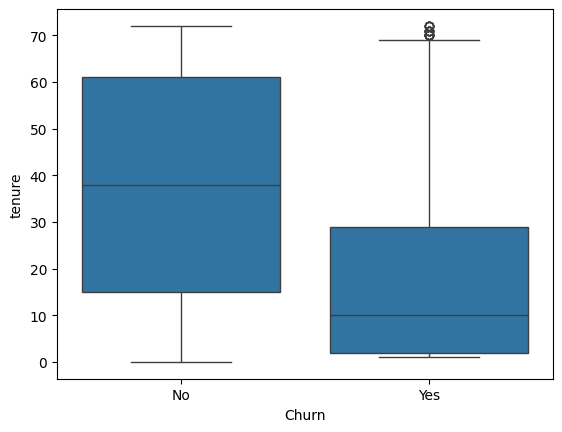

In [139]:
# Finding relationship between Churn and tenurity
sns.boxplot(data=df, x='Churn', y='tenure')

It seems that when Churn is Yes, those customers have spent less time with the company

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SeniorCitizen          7043 non-null   int64  
 1   tenure                 7043 non-null   int64  
 2   InternetService        7043 non-null   object 
 3   OnlineSecurity         7043 non-null   object 
 4   OnlineBackup           7043 non-null   object 
 5   DeviceProtection       7043 non-null   object 
 6   TechSupport            7043 non-null   object 
 7   Contract               7043 non-null   object 
 8   PaperlessBilling       7043 non-null   object 
 9   PaymentMethod          7043 non-null   object 
 10  MonthlyCharges         7043 non-null   float64
 11  TotalCharges           7043 non-null   object 
 12  Churn                  7043 non-null   object 
 13  HaveFamily             7043 non-null   int64  
 14  Has_Streaming_Service  7043 non-null   int64  
dtypes: f

In [141]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [142]:
df[numerical_cols]

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.5
7039,72,103.20,7362.9
7040,11,29.60,346.45
7041,4,74.40,306.6


We need to drop TotalCharges

In [143]:
df.drop('TotalCharges', axis=1, inplace=True)

In [144]:
numerical_cols = ['tenure', 'MonthlyCharges']

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SeniorCitizen          7043 non-null   int64  
 1   tenure                 7043 non-null   int64  
 2   InternetService        7043 non-null   object 
 3   OnlineSecurity         7043 non-null   object 
 4   OnlineBackup           7043 non-null   object 
 5   DeviceProtection       7043 non-null   object 
 6   TechSupport            7043 non-null   object 
 7   Contract               7043 non-null   object 
 8   PaperlessBilling       7043 non-null   object 
 9   PaymentMethod          7043 non-null   object 
 10  MonthlyCharges         7043 non-null   float64
 11  Churn                  7043 non-null   object 
 12  HaveFamily             7043 non-null   int64  
 13  Has_Streaming_Service  7043 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 770.5+ 

In [146]:
df.nunique()

,0
SeniorCitizen,2
tenure,73
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3
Contract,3
PaperlessBilling,2
PaymentMethod,4


Now we would create a baseling model for logistic regression

In [147]:
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

In [148]:
X.head()

,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,HaveFamily,Has_Streaming_Service
0,0,1,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,1,0
1,0,34,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,0,0
2,0,2,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,0,0
3,0,45,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,0,0
4,0,2,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,0,0


In [149]:
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [150]:
categorical_cols = ['SeniorCitizen',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'HaveFamily',
 'Has_Streaming_Service']

numerical_cols = ['tenure', 'MonthlyCharges']

Now we would be splitting the data into train and test

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [152]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5282 entries, 6661 to 5639
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SeniorCitizen          5282 non-null   int64  
 1   tenure                 5282 non-null   int64  
 2   InternetService        5282 non-null   object 
 3   OnlineSecurity         5282 non-null   object 
 4   OnlineBackup           5282 non-null   object 
 5   DeviceProtection       5282 non-null   object 
 6   TechSupport            5282 non-null   object 
 7   Contract               5282 non-null   object 
 8   PaperlessBilling       5282 non-null   object 
 9   PaymentMethod          5282 non-null   object 
 10  MonthlyCharges         5282 non-null   float64
 11  HaveFamily             5282 non-null   int64  
 12  Has_Streaming_Service  5282 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 577.7+ KB


In [153]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1761 entries, 5909 to 3955
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SeniorCitizen          1761 non-null   int64  
 1   tenure                 1761 non-null   int64  
 2   InternetService        1761 non-null   object 
 3   OnlineSecurity         1761 non-null   object 
 4   OnlineBackup           1761 non-null   object 
 5   DeviceProtection       1761 non-null   object 
 6   TechSupport            1761 non-null   object 
 7   Contract               1761 non-null   object 
 8   PaperlessBilling       1761 non-null   object 
 9   PaymentMethod          1761 non-null   object 
 10  MonthlyCharges         1761 non-null   float64
 11  HaveFamily             1761 non-null   int64  
 12  Has_Streaming_Service  1761 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 192.6+ KB


In [154]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 5282 entries, 6661 to 5639
Series name: Churn
Non-Null Count  Dtype
--------------  -----
5282 non-null   int64
dtypes: int64(1)
memory usage: 82.5 KB


In [155]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In the below block, now we would be creating a pipeline

In [156]:
model_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

In [157]:
model_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SeniorCitizen',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'HaveFamily',
                                                   'Has_Streaming_Service'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [158]:
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

In [159]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7995457126632595
Precision: 0.6492146596858639
Recall   : 0.5310492505353319
F1 Score : 0.5842167255594818
ROC AUC  : 0.8416005017392081

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1294
           1       0.65      0.53      0.58       467

    accuracy                           0.80      1761
   macro avg       0.75      0.71      0.73      1761
weighted avg       0.79      0.80      0.79      1761


Confusion Matrix:
[[1160  134]
 [ 219  248]]


Now we need to prepare for random forest classifier

In [160]:
from sklearn.ensemble import RandomForestClassifier

In [161]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [162]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


In [163]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_rf),
        ('classifier', rf_model)
    ]
)

In [165]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SeniorCitizen',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'HaveFamily',
                                                   'Has_Streaming_Service'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [166]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [167]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.7722884724588303
Precision: 0.5868421052631579
Recall   : 0.47751605995717344
F1 Score : 0.526564344746163
ROC AUC  : 0.8106323370257719

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1294
           1       0.59      0.48      0.53       467

    accuracy                           0.77      1761
   macro avg       0.71      0.68      0.69      1761
weighted avg       0.76      0.77      0.76      1761


Confusion Matrix:
[[1137  157]
 [ 244  223]]


Our baseline logistic regression model has performed better on many parameters. SO we would need to tune our model. First we need to find out the feature importances in our random forest model.

In [168]:

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
1,num__MonthlyCharges,0.259632
0,num__tenure,0.240245
19,cat__Contract_Month-to-month,0.055971
16,cat__TechSupport_No,0.033383
7,cat__OnlineSecurity_No,0.032389
26,cat__PaymentMethod_Electronic check,0.032153
5,cat__InternetService_Fiber optic,0.028559
21,cat__Contract_Two year,0.021101
10,cat__OnlineBackup_No,0.020336
29,cat__HaveFamily_1,0.017704


Now time for hyperparameter tuning

In [169]:
from sklearn.model_selection import RandomizedSearchCV

In [170]:
param_distributions = {
    'classifier__n_estimators': [200, 300, 500, 800],

    'classifier__max_depth': [
        None, 5, 8, 12, 16, 20, 30
    ],

    'classifier__min_samples_split': [
        2, 5, 10, 20
    ],

    'classifier__min_samples_leaf': [
        1, 2, 4, 8
    ],

    'classifier__max_features': [
        'sqrt', 'log2', 0.5, 1.0
    ],

    'classifier__class_weight': [
        None, 'balanced', 'balanced_subsample'
    ]
}

In [171]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [172]:
rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['tenure',
                                                                                'MonthlyCharges']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['SeniorCitizen',
                                                                                'InternetService',
                                                                                'OnlineSecurity',
                                                                                'OnlineBackup',
                                                                                'DeviceProtection',
                                                                                'TechSupport',
                                                                                'Contract',
                                                                                'PaperlessBilling',
                                                                                'PaymentMethod',
                                                                                'HaveFamil...
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced',
                                                                     'balanced_subsample'],
                                        'classifier__max_depth': [None, 5, 8,
                                                                  12, 16, 20,
                                                                  30],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     0.5, 1.0],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4, 8],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10,
                                                                          20],
                                        'classifier__n_estimators': [200, 300,
                                                                     500,
                                                                     800]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [173]:
print("Best ROC-AUC:", rf_random_search.best_score_)
print("\nBest Parameters:")
print(rf_random_search.best_params_)

Best ROC-AUC: 0.8435425336348723

Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 16, 'classifier__class_weight': None}


In [174]:
best_rf = rf_random_search.best_estimator_

In [175]:
y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

In [176]:
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Accuracy : 0.7984099943214082
Precision: 0.66
Recall   : 0.49464668094218417
F1 Score : 0.565483476132191
ROC AUC  : 0.8410047691701775

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1294
           1       0.66      0.49      0.57       467

    accuracy                           0.80      1761
   macro avg       0.75      0.70      0.72      1761
weighted avg       0.79      0.80      0.79      1761


Confusion Matrix:
[[1175  119]
 [ 236  231]]


While there is improvement in performance, its still not as good as baseline logistic regression model

In [187]:
from sklearn.model_selection import cross_val_predict

In [188]:
y_proba_oof = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [189]:
import numpy as np
import pandas as pd

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_proba_oof >= threshold).astype(int)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(y_train, y_pred_threshold),
        'recall': recall_score(y_train, y_pred_threshold),
        'f1': f1_score(y_train, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1
0,0.20,0.462032,0.872325,0.604100
1,0.25,0.498922,0.825250,0.621876
2,0.30,0.536672,0.756776,0.627996
3,0.35,0.574592,0.703281,0.632457
4,0.40,0.610204,0.639800,0.624652
5,0.45,0.643987,0.580599,0.610653
6,0.50,0.660594,0.491441,0.563599
7,0.55,0.689988,0.407989,0.512775
8,0.60,0.714744,0.318117,0.440276
9,0.65,0.772926,0.252496,0.380645


In [190]:
best_threshold_row = threshold_results.loc[
    threshold_results['f1'].idxmax()
]

best_threshold = best_threshold_row['threshold']

print("Best threshold:", best_threshold)
print("Precision:", best_threshold_row['precision'])
print("Recall:", best_threshold_row['recall'])
print("F1:", best_threshold_row['f1'])

Best threshold: 0.35
Precision: 0.5745920745920746
Recall: 0.703281027104137
F1: 0.6324567030147531


In [191]:
y_proba_test = best_rf.predict_proba(X_test)[:, 1]

In [192]:
y_pred_threshold = (
    y_proba_test >= best_threshold
).astype(int)

In [193]:
print("Threshold:", best_threshold)

print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

Threshold: 0.35
Accuracy : 0.7745599091425327
Precision: 0.5605536332179931
Recall   : 0.6937901498929336
F1 Score : 0.6200956937799043
ROC AUC  : 0.8410047691701775

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1294
           1       0.56      0.69      0.62       467

    accuracy                           0.77      1761
   macro avg       0.72      0.75      0.73      1761
weighted avg       0.79      0.77      0.78      1761


Confusion Matrix:
[[1040  254]
 [ 143  324]]
